# Mini Projeto 05

# Análise de Churn - Modelagem Estatística e Interpretação de Resultados

---
## 01 - Importação das Bibliotecas

In [1]:
# imports
import pandas as pd
import numpy as np
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
from IPython.display import display, Markdown

In [2]:
# configuracoes para melhor visualizacao
pd.set_option("display.float_format", lambda x: '%.4f' % x)

In [3]:
%reload_ext watermark
%watermark -a "Wolfdata"

Author: Wolfdata



In [4]:
%watermark --iversions

IPython    : 9.13.0
matplotlib : 3.10.9
numpy      : 2.4.4
pandas     : 3.0.2
plotly     : 6.7.0
seaborn    : 0.13.2
statsmodels: 0.14.6



---
## 02 - Definição do Problema de Negócio

In [5]:
display(Markdown(""" 
### 02.1 - Problema de Negócio
                 
A **Connecta Telecon**, uma empresa fictícia de telecomunicações, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média do setor.
                 
A perda de clientes não só impacta a receita recorrente, más também gera custos elevados com a aquisição de novos clientes para substituir os que foram perdidos.
                                 
A diretoria precisa de respostas claras e baseada em dados para a seguinte pergunta:
                 
**"Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"**                 

- Queremos compreender a relação entre variáveis -> Modelagem Estatística
- Se quisermos prever o cancelamento (churn) -> Modelagem Predidita

### 02.2 - Objetivos do Projeto

1. **Identificar os Fatores-Chave:** Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor da fatura) têm um impacto estatisticamente 
siginificativo na probabilidade de um cliente cancelar o serviço.

2. **Quantificaar o Impacto:** Medir o quão forte é a influência de cada fator no risco de churn.

3. **Gerar Recomentações:** Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de clientes.

O modelo escolhido apra esta análise será a **Regressão Logística**, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).

"""))

 
### 02.1 - Problema de Negócio

A **Connecta Telecon**, uma empresa fictícia de telecomunicações, está enfrentando uma taxa de cancelamento de serviços (churn) acima da média do setor.

A perda de clientes não só impacta a receita recorrente, más também gera custos elevados com a aquisição de novos clientes para substituir os que foram perdidos.

A diretoria precisa de respostas claras e baseada em dados para a seguinte pergunta:

**"Quais são os principais fatores que levam nossos clientes a cancelar o serviço?"**                 

- Queremos compreender a relação entre variáveis -> Modelagem Estatística
- Se quisermos prever o cancelamento (churn) -> Modelagem Predidita

### 02.2 - Objetivos do Projeto

1. **Identificar os Fatores-Chave:** Determinar quais variáveis (como tipo de contrato, tempo de fidelidade, valor da fatura) têm um impacto estatisticamente 
siginificativo na probabilidade de um cliente cancelar o serviço.

2. **Quantificaar o Impacto:** Medir o quão forte é a influência de cada fator no risco de churn.

3. **Gerar Recomentações:** Traduzir os resultados da análise estatística em recomendações de negócio acionáveis para a criação de estratégias de retenção de clientes.

O modelo escolhido apra esta análise será a **Regressão Logística**, pois o nosso objetivo é entender a relação entre diversas variáveis e uma variável de resultado binária (Churn: Sim ou Não).



---
## 03 - Extração dos Dados

In [6]:
# funcao para gerar dados ficticios mas coerentes para analise
def gerar_dados_churn(numero_clientes: int = 2000) -> pd.DataFrame:

    # reprodutibilidade
    np.random.seed(42)

    # variaveis
    fidelidade_meses = np.random.randint(1, 73, size = numero_clientes)

    tipo_contrato_opts = ["Mensal", "Anual", "Dois anos"]
    contrato_probs = [0.6, 0.25, 0.15]
    tipo_contrato = np.random.choice(tipo_contrato_opts, size = numero_clientes, p = contrato_probs)

    servico_internet_opts = ["Fibra Óptica", "DSL", "Não"]
    internet_probs = [0.55, 0.35, 0.10]
    servico_internet = np.random.choice(servico_internet_opts, size = numero_clientes, p = internet_probs)

    fatura_base = {
        "Mensal": np.random.normal(60, 20),
        "Anual": np.random.normal(70, 25),
        "Dois anos": np.random.normal(80, 25)
    }

    fatura_mensal = [fatura_base[c] + fidelidade_meses[i] * 0.2 + np.random.normal(0, 5) for i, c in enumerate(tipo_contrato)]
    fatura_mensal = np.clip(fatura_mensal, 20, 120)

    # logica para a probabilidade de churn
    # clientes com contrato mensal, baixa fidelidade e fatura alta tem maior chance de churn
    prob_churn_log = -2.5  # Intercepto base (tendência a não cancelar)
    prob_churn_log += -0.05 * fidelidade_meses  # Mais fidelidade, menor chance
    prob_churn_log += [3.0 if c == 'Mensal' else -1.5 if c == 'Anual' else -2.5 for c in tipo_contrato] # Contrato mensal aumenta muito a chance
    prob_churn_log += [0.8 if s == 'Fibra Óptica' else -0.5 for s in servico_internet] # Fibra tende a ter mais churn (talvez por preço)
    prob_churn_log += 0.03 * fatura_mensal # Fatura mais alta, mais chance

    # Converter log-odds para probabilidade usando a função sigmoide
    prob_churn = 1 / (1 + np.exp(-prob_churn_log))

    # Gerar o resultado de churn com base na probabilidade
    churn = np.random.binomial(1, prob_churn)


    df = pd.DataFrame({
        'ID_Cliente': range(1, numero_clientes + 1),
        'Fidelidade_Meses': fidelidade_meses,
        'Tipo_Contrato': tipo_contrato,
        'Servico_Internet': servico_internet,
        'Fatura_Mensal': fatura_mensal,
        'Churn': churn
    })

    return df

In [7]:
# gerar os dados
df_churn = gerar_dados_churn()

In [8]:
display(Markdown("### Amostra de Dados Gerados"))
df_churn.head()

### Amostra de Dados Gerados

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


---
## 04 - Análise Exploratória de Dados (EDA)

In [9]:
display(Markdown("### Informções Gerais do DataFrame"))
df_churn.info()

### Informções Gerais do DataFrame

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID_Cliente        2000 non-null   int64  
 1   Fidelidade_Meses  2000 non-null   int64  
 2   Tipo_Contrato     2000 non-null   str    
 3   Servico_Internet  2000 non-null   str    
 4   Fatura_Mensal     2000 non-null   float64
 5   Churn             2000 non-null   int64  
dtypes: float64(1), int64(3), str(2)
memory usage: 122.8 KB


In [10]:
# resumo estatistico
display( Markdown("### Resumo Estatístico das Variáveis Numéricas"))
display(df_churn.describe())

### Resumo Estatístico das Variáveis Numéricas

,ID_Cliente,Fidelidade_Meses,Fatura_Mensal,Churn
count,2000.0000,2000.0000,2000.0000,2000.0000
mean,1000.5000,35.6825,75.3201,0.4905
std,577.4946,20.8430,27.5079,0.5000
min,1.0000,1.0000,24.9216,0.0000
25%,500.7500,17.0000,45.0201,0.0000
50%,1000.5000,35.0000,90.6543,0.0000
75%,1500.2500,54.0000,98.5286,1.0000
max,2000.0000,72.0000,119.2712,1.0000


In [11]:
# resumo estatistico
display(Markdown("### Resumo Estatístico das Variáveis Categóricas"))
display(df_churn.describe(include="object"))

### Resumo Estatístico das Variáveis Categóricas

/tmp/ipykernel_280565/1973208372.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  display(df_churn.describe(include="object"))


,Tipo_Contrato,Servico_Internet
count,2000,2000
unique,3,3
top,Mensal,Fibra Óptica
freq,1186,1114


### 04.1 - Gráfico de Taxa de Churn Geral

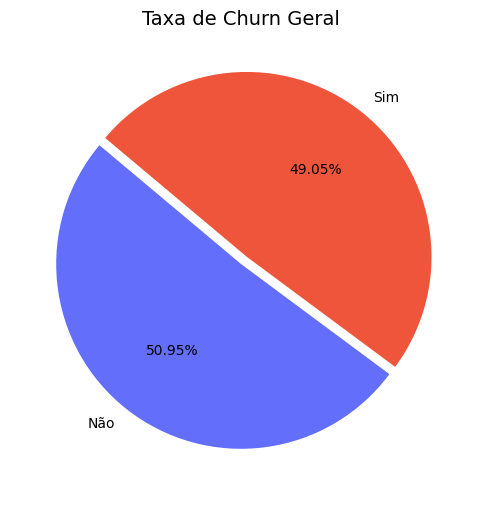

In [12]:
# grafico - versao estatistica

# conta os valroes da coluna 'Chun'
churn_counts = df_churn["Churn"].value_counts().rename(index={1: "Sim", 0: "Não"})

# define as cores equivalentes ao grafico original
cores = ['#636EFA', '#EF553B']

# cria grafico de pizza com duas casas decimais
plt.figure(figsize=(6,6))
plt.pie(
    churn_counts.values,
    labels= churn_counts.index,
    autopct = '%1.2f%%',   # <-- Duas casas decimais
    startangle=140,
    colors=cores,
    explode = [0.05 if label == 'Sim' else 0 for label in churn_counts.index]
)
plt.title("Taxa de Churn Geral", fontsize=14)
plt.show()

In [13]:
# calculamos a taxa de churn
churn_counts = df_churn.Churn.value_counts()
display(churn_counts)


Churn
0    1019
1     981
Name: count, dtype: int64

In [14]:
numerador = churn_counts.get(1, churn_counts.get('Sim', churn_counts.get(True, 0)))
display(numerador)

np.int64(981)

In [15]:
taxa = (100 * numerador) / len(df_churn)
display(taxa)

np.float64(49.05)

In [16]:
display(Markdown(f"""
A taxa de churn geral na nossa base de dados é de **{taxa:.2f}%**.
Este é o nosso principal indicadorr a ser analisado.                 
"""))


A taxa de churn geral na nossa base de dados é de **49.05%**.
Este é o nosso principal indicadorr a ser analisado.                 


### 04.2 - Gráfico de Taxa de Churn Por Tipo de Contrato

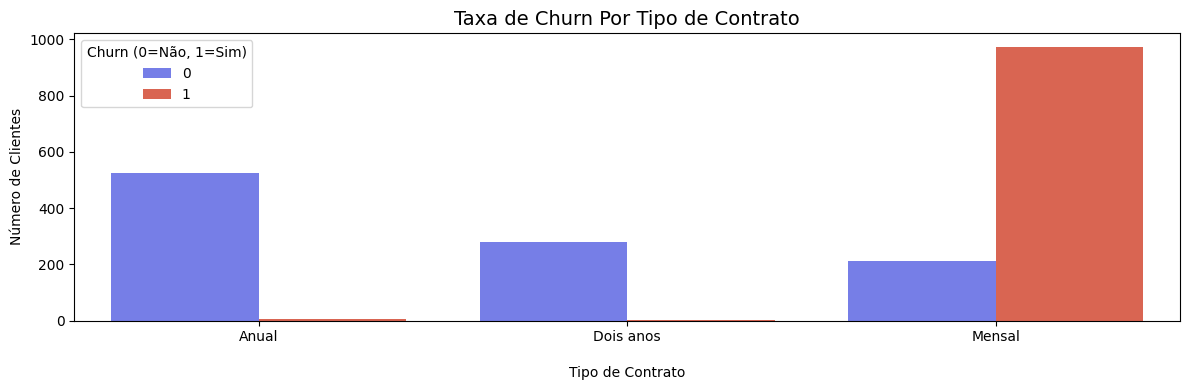

In [17]:
# Gráfico - Versão Estática

plt.figure(figsize = (12,4))

# Cria o gráfico de barras agrupadas com Seaborn
sns.countplot(data = df_churn,
              x = 'Tipo_Contrato',
              hue = 'Churn',
              palette = {0: '#636EFA', 1: '#EF553B'})

plt.title('Taxa de Churn Por Tipo de Contrato', fontsize = 14)
plt.xlabel('\nTipo de Contrato')
plt.ylabel('Número de Clientes')
plt.legend(title = 'Churn (0=Não, 1=Sim)')
plt.xticks(rotation = 0)
plt.tight_layout()
plt.show()

In [18]:
display(Markdown("""
**Conclusão:** A visualização é clara: clientes com **contrato mensal** têm uma propensão ao churn
drasticamente maior em comparação com clientes de contratos anuais ou de dois anos.
"""))


**Conclusão:** A visualização é clara: clientes com **contrato mensal** têm uma propensão ao churn
drasticamente maior em comparação com clientes de contratos anuais ou de dois anos.


### 04.3 - Gráfico de Distribuição da Fidelidade (em meses) Por Churn

In [19]:
# grafico - versao interativa

# analise por fidelidade (Tenuer)
fig_hist_fidelidade = px.histogram(
    df_churn,
    x = "Fidelidade_Meses",
    color = "Churn",
    marginal = "box",
    title = "Distribuição da Fidelidade (em meses) Por Churn",
    labels = {"Fidelidade_Meses": "Meses de Fidelidade"}
)

fig_hist_fidelidade.show()

In [20]:
display(Markdown("""
**Conclusão:** Clientes que cancelam o serviço (Churn=1) estão mais concentrados nos primeiros meses de contrato.
A mediana de fidelidade para clientes que cancelaram é muito menor do que para os que permaneceram.
Isso indica que o início da jornada do cliente é um período crítico para a retenção.
"""))


**Conclusão:** Clientes que cancelam o serviço (Churn=1) estão mais concentrados nos primeiros meses de contrato.
A mediana de fidelidade para clientes que cancelaram é muito menor do que para os que permaneceram.
Isso indica que o início da jornada do cliente é um período crítico para a retenção.


### 04.4 - Gráfico de Distribuição da Fatura Mensal Por Churn

In [21]:
# grafico - versao interativa

# analise por fatura mensal
fig_hist_fatura = px.histogram(
    df_churn,
    x = "Fatura_Mensal",
    color = "Churn",
    marginal = "box",
    title = "Distribuição da Fatura Mensal Por Churn",
    labels = {"Fatura_Mensal": "Valor da Fatura Mensal"}
)

fig_hist_fatura.show()

In [22]:
display(Markdown("""
**Conclusão:** Clientes com faturas mensais mais altas tendem a apresentar uma taxa de churn maior. A mediana do valor da fatura para clientes que cancelaram é notavelmente superior.
"""))


**Conclusão:** Clientes com faturas mensais mais altas tendem a apresentar uma taxa de churn maior. A mediana do valor da fatura para clientes que cancelaram é notavelmente superior.


---
## 05 - Preparação dos Dados Para a Modelagem Estatística

In [23]:
# dados originais
df_churn.head()

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


In [24]:
# categorias da variavel
df_churn.Tipo_Contrato.value_counts()

Tipo_Contrato
Mensal       1186
Anual         533
Dois anos     281
Name: count, dtype: int64

In [25]:
# categorias da variavel
df_churn.Servico_Internet.value_counts()

Servico_Internet
Fibra Óptica    1114
DSL              690
Não              196
Name: count, dtype: int64

In [26]:
# preparacao dos dados
# converter variaveis categoricas em variaveis dummy (0 ou 1)
# adicionado o parametro dtype=int pra garantir que as novas colunas sejam numericas
df_model = pd.get_dummies(df_churn, columns = ["Tipo_Contrato", "Servico_Internet"], drop_first=True, dtype=int)

Variáveis dummy (variáveis indicadoras) são variáveis numéricas criadas para representar categorias em modelos estatísticos ou de machine learning. Elas transformam dados qualitativos (genero, estado civil, regiao, etc...) em valores numéricos, geralmente 0 e 1, permitindo que algoritmos matemáticos consigam melhor processá-los.

Assim, o modelo consegue interpretar diferenças entre grupos sem precisar lidar com texto. As variáveis dummy são uma forma de codificar categorias em números binários, facilitando análises estatísticas e predições. A técnica de criação de variáveis dummy é chamada de One-Hot-Encoding.

In [27]:
# dados originais
df_churn.head()

,ID_Cliente,Fidelidade_Meses,Tipo_Contrato,Servico_Internet,Fatura_Mensal,Churn
0,1,52,Anual,Fibra Óptica,36.5724,0
1,2,15,Dois anos,Fibra Óptica,45.2871,0
2,3,72,Mensal,Fibra Óptica,101.0033,1
3,4,61,Mensal,Fibra Óptica,103.3314,1
4,5,21,Mensal,DSL,94.0969,1


In [28]:
# dados processados
df_model.head()

,ID_Cliente,Fidelidade_Meses,Fatura_Mensal,Churn,Tipo_Contrato_Dois anos,Tipo_Contrato_Mensal,Servico_Internet_Fibra Óptica,Servico_Internet_Não
0,1,52,36.5724,0,0,0,1,0
1,2,15,45.2871,0,1,0,1,0
2,3,72,101.0033,1,0,1,1,0
3,4,61,103.3314,1,0,1,1,0
4,5,21,94.0969,1,0,1,0,0


In [29]:
# resumo dos dados
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   ID_Cliente                     2000 non-null   int64  
 1   Fidelidade_Meses               2000 non-null   int64  
 2   Fatura_Mensal                  2000 non-null   float64
 3   Churn                          2000 non-null   int64  
 4   Tipo_Contrato_Dois anos        2000 non-null   int64  
 5   Tipo_Contrato_Mensal           2000 non-null   int64  
 6   Servico_Internet_Fibra Óptica  2000 non-null   int64  
 7   Servico_Internet_Não           2000 non-null   int64  
dtypes: float64(1), int64(7)
memory usage: 125.1 KB


In [30]:
# definir as variaveis
#-----------------------------------------

# variavel dependente (o que queremos prever)
y = df_model.Churn

In [31]:
# variaveis independentes (as que queremos prever)
# excluimos "ID_Cliente" e a variavel alvo original
X = df_model.drop(["ID_Cliente", "Churn"], axis=1)
X

,Fidelidade_Meses,Fatura_Mensal,Tipo_Contrato_Dois anos,Tipo_Contrato_Mensal,Servico_Internet_Fibra Óptica,Servico_Internet_Não
0,52,36.5724,0,0,1,0
1,15,45.2871,1,0,1,0
2,72,101.0033,0,1,1,0
3,61,103.3314,0,1,1,0
4,21,94.0969,0,1,0,0
...,...,...,...,...,...,...
1995,39,49.1337,1,0,1,0
1996,5,32.8695,1,0,0,0
1997,65,100.8259,0,1,1,0
1998,13,35.9794,0,0,0,0


In [34]:
# adicionamos uma constante (intercepto) ao modelo, exigido pela biblioteca statsmodels
X = sm.add_constant(X)

In [35]:
display(Markdown("#### Amostra dos Dados (X) Preparados para o Modelos"))
display(X.head())

#### Amostra dos Dados (X) Preparados para o Modelos

,const,Fidelidade_Meses,Fatura_Mensal,Tipo_Contrato_Dois anos,Tipo_Contrato_Mensal,Servico_Internet_Fibra Óptica,Servico_Internet_Não
0,1.0000,52,36.5724,0,0,1,0
1,1.0000,15,45.2871,1,0,1,0
2,1.0000,72,101.0033,0,1,1,0
3,1.0000,61,103.3314,0,1,1,0
4,1.0000,21,94.0969,0,1,0,0


In [36]:
display(Markdown("### Amostra dos Dados (y) Preparados para o Modelos"))
display(y.head())

### Amostra dos Dados (y) Preparados para o Modelos

0    0
1    0
2    1
3    1
4    1
Name: Churn, dtype: int64

---
## 06 - Modelagem Estatística
Será criado um modelo para quantificar o impacto de cada variável na probabilidade de churn.

In [37]:
# criacao do modelo
modelo = sm.Logit(y, X)

In [38]:
type(modelo)

statsmodels.discrete.discrete_model.Logit

In [39]:
# treinamento do modelo
modelo_treinado = modelo.fit()

Optimization terminated successfully.
         Current function value: 0.245933
         Iterations 10


In [46]:
# exibir o resumo completo do modelo
display(Markdown("### Resultados do Modelo de Regressão Logística"))
modelo_treinado.summary()

### Resultados do Modelo de Regressão Logística

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.6451
Time:                        18:19:10   Log-Likelihood:                -491.87
converged:                       True   LL-Null:                       -1385.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -5.2263      0.714     -7.316      0.000      -6.627      -3.826
Fidelidade_Meses                 -0.0556      0.006     -9.883      0.000      -0.067      -0.045
Fatura_Mensal                     0.0316      0.016      2.004      0.045       0.001       0.062
Tipo_Contrato_Dois anos          -1.2741      1.075     -1.185      0.236      -3.382       0.834
Tipo_Contrato_Mensal              5.2739      0.934      5.647      0.000       3.443       7.104
Servico_Internet_Fibra Óptica     1.4550      0.180      8.091      0.000       1.103       1.807
Servico_Internet_Não              0.2096      0.264      0.793      0.428      -0.308       0.727
=================================================================================================
"""

In [42]:
display(Markdown("""
O resumo acima contém informações ricas sobre o nosso modelo. Vamos focar nos pontos mais importantes para o negócio:

1.  **Coeficientes (`coef`):** Mostram a direção do impacto. Um coeficiente positivo aumenta a chance de churn, enquanto um negativo a diminui.
2.  **Valor-p (`P>|z|`):** Indica a significância estatística de cada variável. Um valor-p baixo (geralmente < 0.05) significa que o efeito da variável é real e não apenas uma coincidência na amostra.
3.  **Pseudo R-squ.:** Similar ao R² na regressão linear, indica a proporção da "variância" da variável dependente que é explicada pelo modelo. Um valor de 0.645 (ou 65%) é considerado um bom ajuste para este tipo de modelo.

Para facilitar a interpretação, vamos calcular a **Razão de Chances (Odds Ratio)**, que nos diz como as chances de churn mudam com o aumento de uma unidade na variável independente.
"""))


O resumo acima contém informações ricas sobre o nosso modelo. Vamos focar nos pontos mais importantes para o negócio:

1.  **Coeficientes (`coef`):** Mostram a direção do impacto. Um coeficiente positivo aumenta a chance de churn, enquanto um negativo a diminui.
2.  **Valor-p (`P>|z|`):** Indica a significância estatística de cada variável. Um valor-p baixo (geralmente < 0.05) significa que o efeito da variável é real e não apenas uma coincidência na amostra.
3.  **Pseudo R-squ.:** Similar ao R² na regressão linear, indica a proporção da "variância" da variável dependente que é explicada pelo modelo. Um valor de 0.645 (ou 65%) é considerado um bom ajuste para este tipo de modelo.

Para facilitar a interpretação, vamos calcular a **Razão de Chances (Odds Ratio)**, que nos diz como as chances de churn mudam com o aumento de uma unidade na variável independente.


A Razão de Chances (ou Odds Ratio) é uma medida usada para comparar a probabilidade de um evento ocorrer entre dois grupos. Ela é muito comum em estatística e modelos como a regressão logística.

De forma simples, a “chance” (odds) de um evento é a razão entre a probabilidade de ele acontecer e a probabilidade de não acontecer. Por exemplo, se a probabilidade de um cliente comprar um produto é 0,8 (80%), então a chance é 0,8 / 0,2 = 4. Isso quer dizer que a chance de compra é 4 vezes maior do que a de não compra.

In [44]:
# Calcular e exibir as razões de chance (Odds Ratios)
params = modelo_treinado.params
conf = modelo_treinado.conf_int()
conf['Odds Ratio'] = params
conf.columns = ['2.5%', '97.5%', 'Odds Ratio']
conf = np.exp(conf)
display(Markdown("### Tabela de Razão de Chances (Odds Ratio)"))
display(conf)

### Tabela de Razão de Chances (Odds Ratio)

,2.5%,97.5%,Odds Ratio
const,0.0013,0.0218,0.0054
Fidelidade_Meses,0.9355,0.9564,0.9459
Fatura_Mensal,1.0007,1.0644,1.0321
Tipo_Contrato_Dois anos,0.0340,2.3019,0.2797
Tipo_Contrato_Mensal,31.2962,1217.3069,195.1849
Servico_Internet_Fibra Óptica,3.0118,6.0947,4.2844
Servico_Internet_Não,0.7347,2.0697,1.2331


### Interpretação da Razão de Chances Para o Negócio:

**1. const (intercepto)**

O valor 0.0054 representa a chance base de churn quando todas as outras variáveis são zero. Ele por si só não tem interpretação prática relevante e serve como ponto de partida do modelo.

**2. Fidelidade_Meses (0.9459)**

O odds ratio é menor que 1, o que indica um efeito protetor: quanto mais meses de fidelidade, menor a chance de churn. Cada mês adicional reduz em cerca de (1 - 0.9459) × 100 ≈ 5,4% a chance de o cliente cancelar.

**3. Fatura_Mensal (1.0321)**

Um valor ligeiramente acima de 1 mostra que quanto maior a fatura mensal, maior a chance de churn. A cada aumento unitário (por exemplo, R$ 1), a chance cresce em torno de 3,2%. Isso pode indicar insatisfação com preços mais altos.

**4. Tipo_Contrato_Dois anos (0.2797)**

O valor é menor que 1, o que significa que clientes com contrato de dois anos têm menor probabilidade de cancelar comparados ao grupo de referência (por exemplo “Contrato de um ano”). Isso sugere que contratos longos retêm melhor os clientes.

**5. Tipo_Contrato_Mensal (195.1849)**

Um valor muito alto mostra que clientes com contrato mensal têm probabilidade muito maior de cancelar, cerca de 195 vezes maior do que o grupo de referência. Isso é típico: contratos mensais são mais flexíveis e os clientes saem mais facilmente.

**6. Servico_Internet_Fibra Óptica (4.2844)**

Clientes com fibra óptica têm 4,28 vezes mais chance de churn que os que usam outro tipo de internet (como DSL, que seria o grupo base). Pode indicar que esse grupo é mais exigente ou sensível a falhas de serviço.

**7. Servico_Internet_Não (1.2331)**

Clientes sem serviço de internet têm uma chance 23% maior de churn em relação ao grupo base, mas o intervalo de confiança (0.73 a 2.06) inclui 1, o que sugere baixa significância estatística, ou seja, o efeito pode não ser real.

Em resumo:

- Fidelidade e contrato de longo prazo reduzem churn.
- Fatura alta, contrato mensal e fibra óptica aumentam churn.
- O odds ratio mostra o tamanho e a direção do efeito de cada variável sobre a probabilidade de cancelamento.

---
## 08 - Relatório Final - Conclusões e Recomendações Estratégicas

In [45]:
display(Markdown("""
# Relatório Final: Conclusões e Recomendações Estratégicas

## Conclusões

A análise estatística revelou, com alto grau de confiança, os principais impulsionadores do churn de clientes na **Connecta Telecom**. Os resultados do modelo de regressão logística confirmam que o cancelamento está fortemente associado a alguns fatores comportamentais e contratuais específicos. O perfil de cliente com **alto risco de churn** é: **cliente recente, com contrato mensal, fatura elevada e serviço de Fibra Óptica**.

Os fatores mais significativos, em ordem de impacto, são:
1. **Tipo de Contrato:** Clientes com contrato mensal apresentam um risco de cancelamento aproximadamente **195 vezes maior** em relação aos de contratos mais longos. Contratos de dois anos são o principal fator de proteção.
2. **Tempo de Fidelidade:** Cada mês adicional de permanência reduz a chance de churn em cerca de **5%**, mostrando que os primeiros meses são cruciais para a retenção.
3. **Valor da Fatura Mensal:** O aumento no valor da fatura mensal eleva o risco de churn em aproximadamente **3% por unidade monetária**, sugerindo sensibilidade a preço.
4. **Tipo de Serviço de Internet:** O serviço de **Fibra Óptica** aumenta em cerca de **4 vezes** a chance de cancelamento em comparação com o DSL, possivelmente devido a expectativas não atendidas ou à percepção de custo elevado.

## Recomendações Acionáveis

Com base nessas conclusões, propõem-se as seguintes ações estratégicas para o time de retenção:

| Recomendação | Justificativa (Baseada nos Dados) | Ação Proposta |
| :--- | :--- | :--- |
| **1. Incentivar a Migração para Contratos de Longo Prazo** | O contrato mensal está associado a um risco **extremamente alto de churn (≈195x)**. | Criar uma campanha promocional para converter clientes mensais em anuais ou bienais, oferecendo incentivos como descontos, bônus de fidelidade ou upgrades temporários de velocidade. |
| **2. Criar um Programa de Fidelização para Novos Clientes** | Cada mês adicional reduz a chance de churn em **5%**. | Implementar um programa de acompanhamento intensivo nos seis primeiros meses, com comunicações personalizadas, suporte proativo e benefícios progressivos para reforçar a satisfação inicial. |
| **3. Revisar a Estratégia de Preços e Valor Percebido** | Faturas mais altas aumentam a chance de churn em **3%** por unidade. | Segmentar clientes com faturas elevadas e realizar uma análise de elasticidade de preço. Ajustar pacotes para melhorar o valor percebido (mais benefícios pelo mesmo preço). |
| **4. Investigar o Churn no Segmento de Fibra Óptica** | Clientes com Fibra têm **4x mais chances de cancelar**. | Conduzir uma pesquisa de satisfação e uma análise técnica detalhada sobre a qualidade do serviço e suporte. Identificar causas de insatisfação e agir sobre problemas de performance ou atendimento. |

A adoção dessas recomendações, baseadas em evidências estatísticas sólidas e profissionais, permitirá à **Connecta Telecom** reduzir substancialmente o churn, aumentar a fidelização e fortalecer sua base de receita recorrente.
"""))


# Relatório Final: Conclusões e Recomendações Estratégicas

## Conclusões

A análise estatística revelou, com alto grau de confiança, os principais impulsionadores do churn de clientes na **Connecta Telecom**. Os resultados do modelo de regressão logística confirmam que o cancelamento está fortemente associado a alguns fatores comportamentais e contratuais específicos. O perfil de cliente com **alto risco de churn** é: **cliente recente, com contrato mensal, fatura elevada e serviço de Fibra Óptica**.

Os fatores mais significativos, em ordem de impacto, são:
1. **Tipo de Contrato:** Clientes com contrato mensal apresentam um risco de cancelamento aproximadamente **195 vezes maior** em relação aos de contratos mais longos. Contratos de dois anos são o principal fator de proteção.
2. **Tempo de Fidelidade:** Cada mês adicional de permanência reduz a chance de churn em cerca de **5%**, mostrando que os primeiros meses são cruciais para a retenção.
3. **Valor da Fatura Mensal:** O aumento no valor da fatura mensal eleva o risco de churn em aproximadamente **3% por unidade monetária**, sugerindo sensibilidade a preço.
4. **Tipo de Serviço de Internet:** O serviço de **Fibra Óptica** aumenta em cerca de **4 vezes** a chance de cancelamento em comparação com o DSL, possivelmente devido a expectativas não atendidas ou à percepção de custo elevado.

## Recomendações Acionáveis

Com base nessas conclusões, propõem-se as seguintes ações estratégicas para o time de retenção:

| Recomendação | Justificativa (Baseada nos Dados) | Ação Proposta |
| :--- | :--- | :--- |
| **1. Incentivar a Migração para Contratos de Longo Prazo** | O contrato mensal está associado a um risco **extremamente alto de churn (≈195x)**. | Criar uma campanha promocional para converter clientes mensais em anuais ou bienais, oferecendo incentivos como descontos, bônus de fidelidade ou upgrades temporários de velocidade. |
| **2. Criar um Programa de Fidelização para Novos Clientes** | Cada mês adicional reduz a chance de churn em **5%**. | Implementar um programa de acompanhamento intensivo nos seis primeiros meses, com comunicações personalizadas, suporte proativo e benefícios progressivos para reforçar a satisfação inicial. |
| **3. Revisar a Estratégia de Preços e Valor Percebido** | Faturas mais altas aumentam a chance de churn em **3%** por unidade. | Segmentar clientes com faturas elevadas e realizar uma análise de elasticidade de preço. Ajustar pacotes para melhorar o valor percebido (mais benefícios pelo mesmo preço). |
| **4. Investigar o Churn no Segmento de Fibra Óptica** | Clientes com Fibra têm **4x mais chances de cancelar**. | Conduzir uma pesquisa de satisfação e uma análise técnica detalhada sobre a qualidade do serviço e suporte. Identificar causas de insatisfação e agir sobre problemas de performance ou atendimento. |

A adoção dessas recomendações, baseadas em evidências estatísticas sólidas e profissionais, permitirá à **Connecta Telecom** reduzir substancialmente o churn, aumentar a fidelização e fortalecer sua base de receita recorrente.


---
### Interpretação por IA (Chatgpt)
---

In [47]:
# exibir o resumo completo do modelo
display(Markdown("### Resultados do Modelo de Regressão Logística"))
modelo_treinado.summary()

### Resultados do Modelo de Regressão Logística

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                  Churn   No. Observations:                 2000
Model:                          Logit   Df Residuals:                     1993
Method:                           MLE   Df Model:                            6
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.6451
Time:                        18:20:25   Log-Likelihood:                -491.87
converged:                       True   LL-Null:                       -1385.9
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -5.2263      0.714     -7.316      0.000      -6.627      -3.826
Fidelidade_Meses                 -0.0556      0.006     -9.883      0.000      -0.067      -0.045
Fatura_Mensal                     0.0316      0.016      2.004      0.045       0.001       0.062
Tipo_Contrato_Dois anos          -1.2741      1.075     -1.185      0.236      -3.382       0.834
Tipo_Contrato_Mensal              5.2739      0.934      5.647      0.000       3.443       7.104
Servico_Internet_Fibra Óptica     1.4550      0.180      8.091      0.000       1.103       1.807
Servico_Internet_Não              0.2096      0.264      0.793      0.428      -0.308       0.727
=================================================================================================
"""

## Interpretação:

Esse resultado é o resumo estatístico de um modelo de Regressão Logística (Logit) usando o statsmodels.
O objetivo do modelo é prever a variável:

- Churn → normalmente significa se o cliente cancelou ou não o serviço.

#### 1. O que é esse modelo?

A regressão logística é usada quando a variável alvo é binária:

- 0 = não cancelou
- 1 = cancelou

Ela não prevê valores contínuos como a regressão linear.
Ela prevê a probabilidade de um evento acontecer.

Neste caso:

**P(Churn=1)**

Ou seja:

**“Qual a probabilidade deste cliente cancelar?”**

#### 2. Visão geral do modelo

O statsmodels é extremamente importante para:

- interpretação estatística;
- inferência;
- análise de significância;
- entendimento do impacto das variáveis.

**Enquanto o scikit-learn é mais focado em performance e pipeline de ML.**

#### 3. Interpretação do cabeçalho

**Variável dependente**

Dep. Variable: Churn

A variável que o modelo tenta prever é o churn.

Número de observações
No. Observations: 2000

Você treinou o modelo com 2000 registros.

Método
Method: MLE

MLE = Maximum Likelihood Estimation.

A regressão logística não usa mínimos quadrados como regressão linear.
Ela usa maximização da verossimilhança.

O modelo procura os coeficientes que maximizam a probabilidade de observar os dados reais.

- converged: True
- converged: True

Excelente sinal.

Significa que o algoritmo conseguiu encontrar uma solução estável.

Se fosse False, o modelo poderia estar inválido.

4. Qualidade geral do modelo
Pseudo R²
Pseudo R-squ.: 0.6451

Na regressão logística não existe R² tradicional.

Então usamos pseudo-R².

Valor:

0.6451

Isso é MUITO bom para modelos de churn.

Em problemas reais:

- 0.2 já pode ser útil;
- 0.4 é forte;
- acima de 0.6 é excelente.

Significa que o modelo consegue explicar bem o comportamento do churn.

- LLR p-value
- LLR p-value: 0.000

Esse é um dos resultados MAIS IMPORTANTES.

Ele testa:

“O modelo inteiro é estatisticamente melhor do que um modelo vazio?”

Como o valor é praticamente zero:

✅ O modelo é estatisticamente significativo.

Ou seja:

as variáveis ajudam de verdade;
o modelo encontrou padrões reais;
não é ruído aleatório.
5. Como interpretar os coeficientes

Na regressão logística:

- coeficiente positivo → aumenta chance de churn;
- coeficiente negativo → reduz chance de churn.

Mas atenção:

Os coeficientes estão em log-odds, não em porcentagem direta.

Mesmo assim, o sinal já permite interpretação muito útil.

6. Interpretação variável por variável
Fidelidade_Meses
coef = -0.0556
p-value = 0.000
Interpretação

Quanto mais tempo o cliente permanece na empresa:

✅ menor a chance de churn.

Isso faz total sentido de negócio.

Clientes antigos tendem a:

confiar mais;
ter hábito consolidado;
possuir dependência do serviço.
Significância
p-value = 0.000

Extremamente significativo.

Essa variável é MUITO importante.

Interpretação prática

Cada mês adicional reduz a probabilidade de churn.

O efeito é consistente e confiável.

Fatura_Mensal
coef = 0.0316
p-value = 0.045
Interpretação

Quanto maior a fatura:

✅ maior a chance de churn.

Isso também faz sentido.

Clientes com contas maiores:

sentem mais impacto financeiro;
ficam mais sensíveis a preço;
podem buscar concorrentes.
Significância
p-value = 0.045

Significativo, mas marginalmente.

Está perto do limite clássico de 0.05.

Então:

a variável ajuda;
mas o efeito não é tão forte quanto outras.
Tipo_Contrato_Dois anos
coef = -1.2741
p-value = 0.236
Interpretação do coeficiente

Contrato de dois anos reduz churn.

Isso faz sentido:

contratos longos aumentam retenção;
existe compromisso contratual.
MAS…
p-value = 0.236

Essa variável NÃO foi estatisticamente significativa.

Ou seja:

⚠️ o modelo não tem evidência forte suficiente para afirmar que esse efeito é real.

Possíveis causas:

poucos clientes nesse grupo;
multicolinearidade;
variabilidade alta;
amostra insuficiente.
Tipo_Contrato_Mensal
coef = 5.2739
p-value = 0.000

Essa é provavelmente a variável MAIS FORTE do modelo.

Interpretação

Clientes com contrato mensal possuem MUITO maior probabilidade de churn.

Faz total sentido de negócio:

não existe fidelização;
cliente pode sair a qualquer momento;
baixa barreira de cancelamento.
Importância

Coeficiente extremamente alto:

5.2739

Na prática isso representa um aumento gigantesco nas odds de churn.

Significância
p-value = 0.000

Altamente significativa.

Essa variável é decisiva.

Serviço_Internet_Fibra Óptica
coef = 1.4550
p-value = 0.000
Interpretação

Clientes com fibra óptica apresentam maior chance de churn.

Isso parece estranho inicialmente, mas em negócios reais pode indicar:

clientes premium mais exigentes;
maior concorrência nesse segmento;
problemas de qualidade;
preço elevado.
Significância

Muito significativa.

Provavelmente existe um padrão importante aqui.

Serviço_Internet_Não
coef = 0.2096
p-value = 0.428

Não significativo.

O modelo não encontrou evidência suficiente de impacto real dessa variável.

7. Interpretação dos intervalos de confiança

Exemplo:

[0.025 0.975]

É o intervalo de confiança de 95%.

Se o intervalo cruza zero:

⚠️ a variável tende a não ser significativa.

Exemplo:

Tipo_Contrato_Dois anos:
[-3.382 ; 0.834]

Cruza zero.

Logo:

❌ não significativo.

Já no contrato mensal:

[3.443 ; 7.104]

Todo positivo.

Logo:

✅ efeito claramente positivo.

8. O que esse modelo está dizendo no negócio?

O modelo conta uma história MUITO coerente:

Clientes mais propensos ao churn
contratos mensais;
contas mais altas;
clientes de fibra óptica;
pouco tempo de relacionamento.
Clientes menos propensos ao churn
clientes antigos;
contratos longos.
9. O que isso significa para uma empresa?

Esse modelo já permitiria:

Campanhas de retenção

Focar em:

clientes novos;
contratos mensais;
contas altas.
Estratégias comerciais

Incentivar:

migração para contratos longos;
programas de fidelidade.
Monitoramento preventivo

Criar score de risco de churn.

10. Uma observação MUITO importante

Os coeficientes da regressão logística NÃO são probabilidades.

O correto seria converter para:

Odds Ratio

Usando:

e
coef

Por exemplo:

Para contrato mensal:

e
5.2739

Isso gera uma odds ratio gigantesca.

Ou seja:

clientes mensais possuem odds MUITO maiores de cancelar.

11. Seu modelo parece bom?

Sim.

Pelos resultados:

✅ Modelo convergiu
✅ Variáveis importantes fazem sentido de negócio
✅ Pseudo R² alto
✅ Modelo estatisticamente significativo
✅ Interpretação coerente
✅ Sinais esperados

Isso é MUITO importante em Data Science real.

Porque um modelo bom não é só performance.

Ele precisa:

fazer sentido;
ser explicável;
ser interpretável;
gerar ação de negócio.

E esse modelo conseguiu isso muito bem.

